In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import jaro
from collections import defaultdict

In [137]:
# primer paso: descargar el dataset desde https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes

In [138]:
# Cargar el conjunto de datos de accidentes de tránsito en Nueva York
df_Motor_Vehicle_Collisions = pd.read_csv('./Motor_Vehicle_Collisions_-_Crashes.csv', on_bad_lines='skip')

C:\Users\PC\AppData\Local\Temp\ipykernel_17348\2569441024.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_Motor_Vehicle_Collisions = pd.read_csv('./Motor_Vehicle_Collisions_-_Crashes.csv', on_bad_lines='skip')


# Descripción del dataset

El dataset seleccionado corresponde al registro de colisiones vehiculares en la ciudad de Nueva York, publicado en el portal oficial de Datos Abiertos de la Ciudad de Nueva York y elaborado por el Departamento de Policía de Nueva York (NYPD).
Este conjunto de datos, titulado “Motor Vehicle Collisions – Crashes”, contiene información detallada sobre todos los accidentes de tránsito reportados por la policía, incluyendo fecha, hora, ubicación, tipo de vehículo involucrado, causas contribuyentes y número de personas heridas o fallecidas.

Cada fila representa un evento de colisión individual, y las columnas describen distintas características del mismo. Los datos abarcan variables numéricas, categóricas y geográficas, lo que permite realizar un análisis exploratorio amplio sobre los patrones de accidentalidad, la distribución espacial y temporal de los siniestros, y las causas más frecuentes asociadas a los incidentes.

Según la documentación oficial, el dataset se basa en los formularios MV-104AN, que los agentes deben completar para todos los accidentes que resulten en lesiones, muertes o daños materiales superiores a 1000 dólares. Estos datos se gestionan dentro del sistema Finest Online Records Management System (FORMS), implementado por el NYPD desde 2016, como parte de la iniciativa Vision Zero, cuyo objetivo es eliminar las muertes por accidentes de tránsito.

[dataset: https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes](https://catalog.data.gov/dataset/motor-vehicle-collisions-crashes) 

### Diccionario de variables principales

| Variable                        | Descripción                                                          | Tipo de dato |
| ------------------------------- | -------------------------------------------------------------------- | ------------ |
| `CRASH_DATE`                    | Fecha en la que ocurrió la colisión                                  | Fecha        |
| `CRASH_TIME`                    | Hora exacta del incidente                                            | Hora         |
| `BOROUGH`                       | Distrito o municipio donde ocurrió el hecho                          | Categórico   |
| `NUMBER_OF_PEDESTRIANS_INJURED` | Peatones heridos en el accidente                                     | Numérico     |
| `NUMBER_OF_PEDESTRIANS_KILLED`  | Peatones fallecidos en el accidente                                  | Numérico     |
| `NUMBER_OF_CYCLIST_INJURED`     | Ciclistas heridos                                                    | Numérico     |
| `NUMBER_OF_CYCLIST_KILLED`      | Ciclistas fallecidos                                                 | Numérico     |
| `NUMBER_OF_MOTORIST_INJURED`    | Conductores heridos                                                  | Numérico     |
| `NUMBER_OF_MOTORIST_KILLED`     | Conductores fallecidos                                               | Numérico     |
| `NUMBER_OF_PERSONS_INJURED`     | Total de personas heridas en el accidente                            | Numérico     |
| `NUMBER_OF_PERSONS_KILLED`      | Total de personas fallecidas en el accidente                         | Numérico     |
| `VEHICLE_TYPE_CODE_1`           | Tipo del primer vehículo involucrado                                 | Categórico   |
| `CONTRIBUTING_FACTOR_VEHICLE_1` | Factor o causa contribuyente asociada al primer vehículo involucrado | Categórico   |


### Otras variables

| Variable                          | Descripción                                                          | Tipo de dato     |
| --------------------------------- | -------------------------------------------------------------------- | ---------------- |
| `COLLISION_ID`                    | Identificador único del evento de colisión                           | Numérico         |
| `ZIP_CODE`                        | Código postal del lugar del incidente                                | Texto            |
| `LATITUDE` / `LONGITUDE`          | Coordenadas geográficas del lugar del siniestro                      | Numérico         |
| `LOCATION`                        | tupla (latitud, longitud) del lugar del siniestro                    | Texto            |
| `ON_STREET_NAME`                  | Calle donde ocurrió la colisión                                      | Texto            |
| `CROSS_STREET_NAME`               | Calle transversal más cercana                                        | Texto            |
| `OFF_STREET_NAME`                 | Calle fuera de la vía principal donde ocurrió el hecho               | Texto            |
| `CONTRIBUTING_FACTOR_VEHICLE_2–5` | Factores contribuyentes asociados a los demás vehículos involucrados | Texto / Categórico       |
| `VEHICLE_TYPE_CODE_2–5`           | Tipos de los otros vehículos involucrados en la colisión             | Texto / Categórico       |


# Limpieza y transformación de datos

In [139]:
df_crashes = df_Motor_Vehicle_Collisions.copy()

In [140]:
#  Normalizar nombres de columnas

df_crashes.columns = (
    df_crashes.columns
    .str.strip()         
    .str.lower()          
    .str.replace(' ', '_')
)

In [141]:
df_crashes["on_street_name"] = df_crashes["on_street_name"].str.upper().str.strip()
df_crashes["cross_street_name"] = df_crashes["cross_street_name"].str.upper().str.strip()
df_crashes["off_street_name"] = df_crashes["off_street_name"].str.upper().str.strip()

df_crashes['vehicle_type_code_1'] = df_crashes['vehicle_type_code_1'].str.lower().str.strip()
df_crashes['vehicle_type_code_2'] = df_crashes['vehicle_type_code_2'].str.lower().str.strip()
df_crashes['vehicle_type_code_3'] = df_crashes['vehicle_type_code_3'].str.lower().str.strip()
df_crashes['vehicle_type_code_4'] = df_crashes['vehicle_type_code_4'].str.lower().str.strip()
df_crashes['vehicle_type_code_5'] = df_crashes['vehicle_type_code_5'].str.lower().str.strip()

In [142]:
# mostrar todos los registros que tienen id duplicado "collision_id"

df_crashes[df_crashes.duplicated(subset=['collision_id'], keep=False)]
# no hay registros duplicados

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,off_street_name,...,contributing_factor_vehicle_2,contributing_factor_vehicle_3,contributing_factor_vehicle_4,contributing_factor_vehicle_5,collision_id,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5


In [143]:
# Fechas

df_crashes['crash_datetime'] = pd.to_datetime(
    df_crashes['crash_date'] + ' ' + df_crashes['crash_time'],
    errors='coerce'
)

df_crashes['hour'] = df_crashes['crash_datetime'].dt.hour
df_crashes['week_day'] = df_crashes['crash_datetime'].dt.day_name()
df_crashes['day'] = df_crashes['crash_datetime'].dt.day
df_crashes['month'] = df_crashes['crash_datetime'].dt.month
df_crashes['year'] = df_crashes['crash_datetime'].dt.year

In [144]:
(df_crashes.isna().sum() / len(df_crashes) * 100)[lambda s: s > 0].sort_values(ascending=False)

# se puede ver que las columnas vehicle_type_code_3, vehicle_type_code_4, vehicle_type_code_5 tienen muchos NaN
# tambien las columnas contributing_factor_vehicle_3, contributing_factor_vehicle_4, contributing_factor_vehicle_5 

vehicle_type_code_5              99.561950
contributing_factor_vehicle_5    99.547711
vehicle_type_code_4              98.408429
contributing_factor_vehicle_4    98.348502
vehicle_type_code_3              93.046118
contributing_factor_vehicle_3    92.765364
off_street_name                  82.385028
cross_street_name                38.209562
zip_code                         30.654656
borough                          30.642265
on_street_name                   21.777128
vehicle_type_code_2              20.052636
contributing_factor_vehicle_2    16.048543
latitude                         10.829426
longitude                        10.829426
location                         10.829426
vehicle_type_code_1               0.727050
contributing_factor_vehicle_1     0.352982
number_of_persons_killed          0.001397
number_of_persons_injured         0.000811
dtype: float64

In [145]:
# dropeo las columnas vehicle_type_code_3, vehicle_type_code_4, vehicle_type_code_5 y las convierto en una columna categórica "multiple_crash"
df_crashes['multiple_crash'] = df_crashes[['vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5']].notna().any(axis=1)

df_crashes.drop(columns=['vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5'], inplace=True)
df_crashes.drop(columns=['contributing_factor_vehicle_3', 'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5'], inplace=True)

In [146]:
# Creo una lista para orientarme como agrupar los tipos de vehiculos 
# no se modifica o crea nada, es solo para crear el diccionario de mapeo

vehicle_counts = df_crashes['vehicle_type_code_1'].value_counts()

# Filtrar vehículos con más de 20 apariciones
vehicles = vehicle_counts[vehicle_counts > 20].index.tolist()

base_categories = ['sedan', 'suv', 'pickup', 'bus', 'motorcycle', 'van', 'truck', 'ambulance']

# Umbral de similitud
threshold = 0.7

groups = defaultdict(list)

for v in vehicles:
    v_str = str(v) if pd.notna(v) else ''
    best_score = 0
    best_cat = None
    for cat in base_categories:
        score = jaro.jaro_winkler_metric(v_str, cat)
        if score > best_score:
            best_score = score
            best_cat = cat
    if best_score >= threshold:
        groups[best_cat].append(v)
    else:
        groups['other'].append(v)


# Mostrar grupos con cantidad
for cat, items in groups.items():
    print(f"\n{cat.upper()} ({len(items)} vehículos):")
    for item in items:
        print(f" - {item} ({vehicle_counts[item]} apariciones)")



SEDAN (1 vehículos):
 - sedan (641330 apariciones)

OTHER (99 vehículos):
 - station wagon/sport utility vehicle (502356 apariciones)
 - passenger vehicle (416206 apariciones)
 - sport utility / station wagon (180291 apariciones)
 - taxi (87733 apariciones)
 - 4 dr sedan (40187 apariciones)
 - box truck (26576 apariciones)
 - other (22973 apariciones)
 - unknown (19960 apariciones)
 - bike (18078 apariciones)
 - large com veh(6 or more tires) (14397 apariciones)
 - small com veh(4 tires) (13216 apariciones)
 - tractor truck diesel (11315 apariciones)
 - livery vehicle (10481 apariciones)
 - dump (4379 apariciones)
 - e-bike (4190 apariciones)
 - convertible (4184 apariciones)
 - moped (3329 apariciones)
 - e-scooter (2749 apariciones)
 - 2 dr sedan (2653 apariciones)
 - flat bed (2653 apariciones)
 - garbage or refuse (2600 apariciones)
 - carry all (2094 apariciones)
 - tractor truck gasoline (1693 apariciones)
 - chassis cab (997 apariciones)
 - fire truck (981 apariciones)
 - tanke

In [147]:
mapping_type_vehicles = {
    "sedan": [
        "sedan", "4 dr sedan", "2 dr sedan", "3-door", "sudn", "4sedn", "sedona",
        "4 door", "2 door", "4 dr", "4-door", "sd", "sea", "se", "4dsdn",
        "4d sedan", "4d sdn", "passenger vehicle", "taxi", "car"
    ],

    "suv": [
        "suv", "station wagon/sport utility vehicle", "sport utility / station wagon",
        "sw/suv", "station wagon", "wagon", "sport utility", "subn"
    ],

    "pickup": [
        "pick-up truck", "pick up", "pickup", "picku", "pick-up tr", "pickup tru",
        "pickup tow", "pk", "pickup with mounted camper", "pick", "pick up tr",
        "pc", "pick-", "pick-up", "pickup truck", "pick up trk"
    ],

    "bus": [
        "bus", "school bus", "mini bus", "mta bus", "nyc bus", "shuttle bu",
        "school  bu", "yellowbus", "bus (omnib)", "coach", "shuttle"
    ],

    "motorcycle": [
        "motorcycle", "motorscooter", "motorscoot", "mc", "mcy", "motorbike", "e-bike",
        "moped", "motor scoo", "motor", "mo-ped", "minicycle", "bicycle", "scooter",
        "e-scooter", "e-sco", "scoot", "minibike", "pedicab", "bike", "e-bik"
    ],

    "van": [
        "van", "refrigerated van", "van camper", "van truck", "vanette", "rv/van",
        "camper van", "van/b", "van w", "van/truck", "van wh", "van t", "sprinter v",
        "utility", "cargo van", "usps", "usps truck"
    ],

    "truck": [
        "box truck", "dump", "tractor truck diesel", "tractor truck gasoline",
        "flat bed", "tanker", "delivery t", "freight", "semi", "flatbed", "tractor tr",
        "dump truck", "truck", "freightlin", "freight tr", "tow truck / wrecker",
        "tract", "trac", "tr", "tow truck", "tow", "tow t", "stake or rack",
        "flat rack", "flat", "chassis cab", "armored truck"
    ],

    "ambulance": [
        "ambulance", "ambu", "ambul", "ambulence", "ambulette", "ambulane", "ems",
        "fdny ambul", "fdny ems", "ems fdny", "amb", "nys ambula"
    ],

    # Carga pesada
    "cargo": [
        "tractor truck", "tractor truck diesel", "tractor truck gasoline",
        "freight truck", "freight", "flat bed", "tanker", "trailer", "trail",
        "semi truck", "flat rack", "stake or rack", "bulk agriculture",
        "hopper", "freig", "trk", "trailer truck"
    ],

    # Emergencias (no ambulancias)
    "emergency": [
        "fire truck", "firetruck", "fdny", "fdny truck", "fdny fire", "fire", "firet",
        "fdny vehicle", "fire veh", "fdny firetr", "fire dept"
    ],

    # Servicios públicos
    "service": [
        "garbage or refuse", "garbage truck", "sanitation", "sanit", "dump truck",
        "street sweeper", "stree", "recycling", "snow plow", "sweepr", "utility truck",
        "pallet", "forklift", "fork lift", "fork", "lift boom", "fdny truck", "fdny fire"
    ],

    "special": [
        "golf cart", "motorized home", "rv", "limo", "livery vehicle", "taxi limo",
        "beverage truck", "food truck", "lunch wagon", "minivan", "pas", "carry all",
        "chassis cab", "convertible", "open body", "deliv", "delv", "commercial",
        "comme", "com", "util", "utili"
    ],

    # Otros (residuales o desconocidos)
    "other": [
        "unk", "unkno", "unknown", "other", "standing s", "self", "posta", "ford",
        "fdny", "fdny truck", "bulk", "unknown type", "misc", "none"
    ]
}

In [ ]:
# Función para mapear los tipos de vehículos
def unify_vehicle_type(x):
    for key, variants in mapping_type_vehicles.items():
        if x in variants:
            return key
    return "other" 

df_crashes['vehicle_type_code_1'] = df_crashes['vehicle_type_code_1'].apply(unify_vehicle_type)
df_crashes['vehicle_type_code_2'] = df_crashes['vehicle_type_code_2'].apply(unify_vehicle_type)

summary1 = df_crashes["vehicle_type_code_1"].value_counts()
summary2 = df_crashes["vehicle_type_code_2"].value_counts()
display(summary1)
display(summary2)

vehicle_type_code_1
sedan         1188476
suv            682916
other           90694
pickup          52869
truck           51865
motorcycle      45210
bus             38616
van             36316
special         18194
ambulance        8858
service          3199
emergency        1604
cargo             562
Name: count, dtype: int64

vehicle_type_code_2
sedan         858685
other         580786
suv           495065
motorcycle     88998
truck          56754
pickup         47539
bus            33528
van            33190
special        14629
ambulance       4803
service         3122
emergency       1568
cargo            712
Name: count, dtype: int64

In [149]:
# Las convierto en categóricas
df_crashes['vehicle_type_code_1'] = df_crashes['vehicle_type_code_1'].astype('category')
df_crashes['vehicle_type_code_2'] = df_crashes['vehicle_type_code_2'].astype('category')

# Análisis exploratorio de los datos

### Choques por hora del día

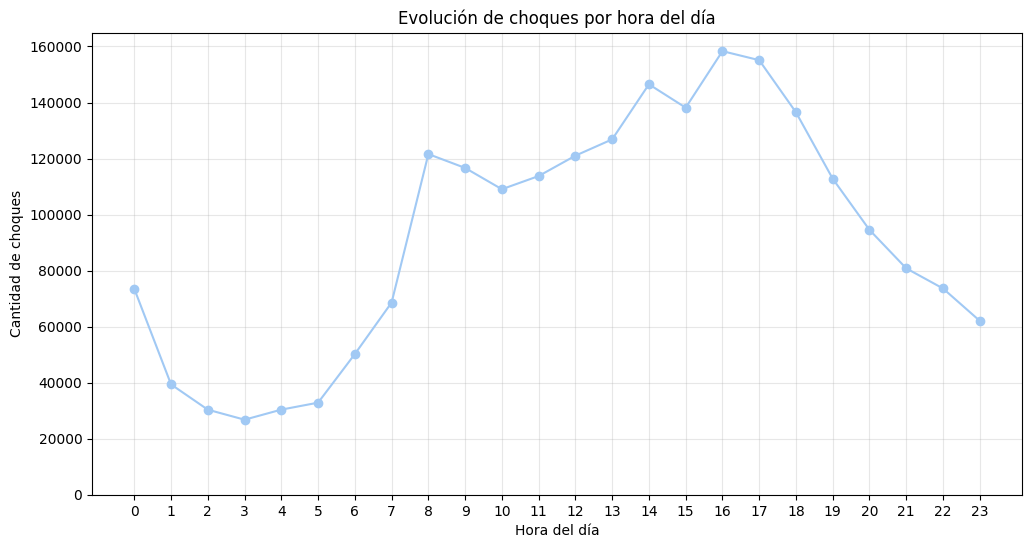

In [150]:
choques_hora = (
    df_crashes.groupby('hour')['collision_id']
      .count()
      .reset_index(name='cantidad_choques')
      .sort_values('hour')
)

plt.figure(figsize=(12, 6))
plt.plot(choques_hora['hour'], choques_hora['cantidad_choques'], marker='o')
plt.title("Evolución de choques por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Cantidad de choques")
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.ylim(bottom=0)  
plt.show()


Se puede apreciar que el rango horario con mayor cantidad de choques coincide con los horarios habituales de desplazamiento hacia y desde el trabajo.

El primer salto grande de los choques sucede a las 8hs, y los picos se producen a las 16hs y 17hs, en el horario de salida laboral, probablemente por el cansancio acumulado de la jornada, los conductores tienen menos atención en la conducción, además de la congestión vehicular típica de esos horarios.

### calles con mas choques

C:\Users\PC\AppData\Local\Temp\ipykernel_17348\655003895.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=choques_calle, y='calle', x='cantidad_choques',


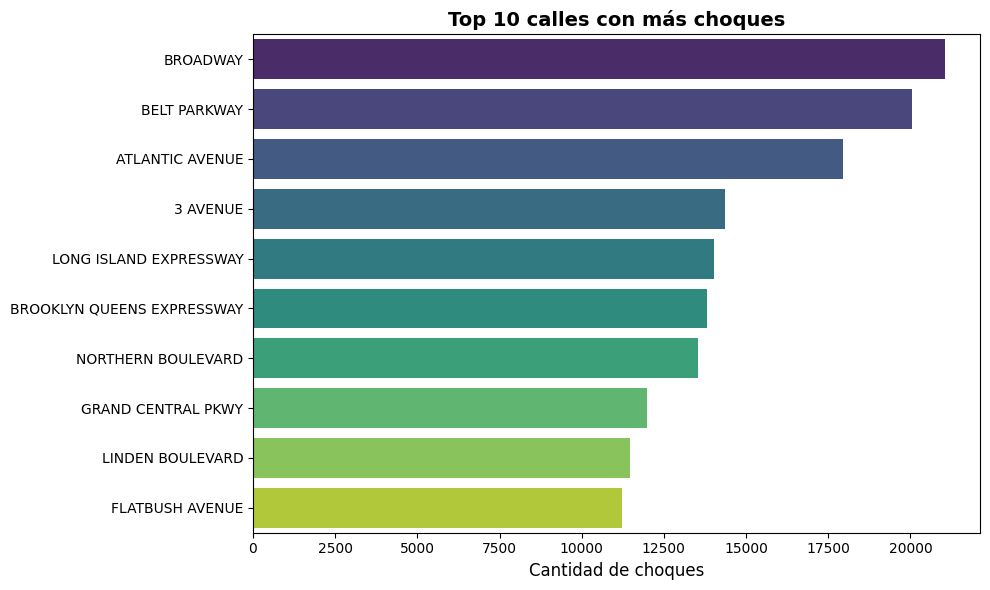

In [151]:
choques_calle = (
    df_crashes['on_street_name']
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={'on_street_name': 'calle', 'count': 'cantidad_choques'})
)


plt.figure(figsize=(10, 6))
sns.barplot(data=choques_calle, y='calle', x='cantidad_choques', 
            palette='viridis', order=choques_calle.sort_values('cantidad_choques', ascending=False)['calle'])
plt.title("Top 10 calles con más choques", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de choques", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

### esquinas con mas choques

C:\Users\PC\AppData\Local\Temp\ipykernel_17348\3856500368.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=choques_esquina, y='esquina_str', x='cantidad_choques',


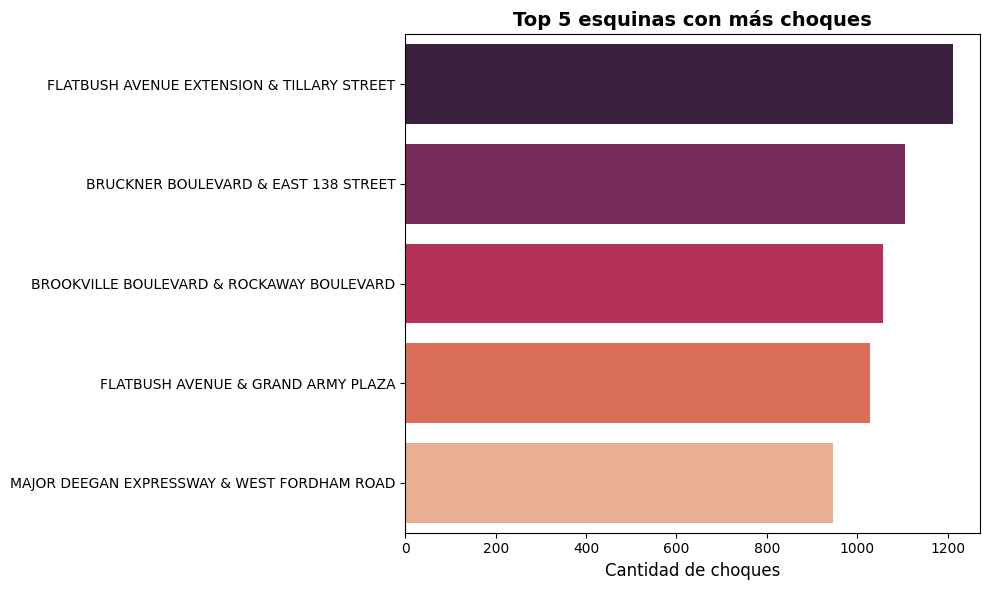

In [ ]:
choques_esquina = (
    df_crashes[['on_street_name', 'cross_street_name']]
    .dropna()  
    # "calle A & calle B" es lo mismo que "calle B & calle A"
    .apply(lambda x: tuple(sorted([x['on_street_name'], x['cross_street_name']])), axis=1)
    .value_counts()
    .head(5)
    .reset_index()
    .rename(columns={'index': 'esquina', 'count': 'cantidad_choques'})  # ← Cambiado 'count' por 0
)

# Convertir las tuplas a strings legibles
choques_esquina['esquina_str'] = choques_esquina['esquina'].apply(lambda x: f"{x[0]} & {x[1]}")

plt.figure(figsize=(10, 6))
sns.barplot(data=choques_esquina, y='esquina_str', x='cantidad_choques', 
            palette='rocket', 
            order=choques_esquina.sort_values('cantidad_choques', ascending=False)['esquina_str'])
plt.title("Top 5 esquinas con más choques", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de choques", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

La intersección con mayor cantidad de choques es la ubicada entre Flatbush Avenue Extension y Tillary Street, en el distrito de Brooklyn. Durante el período analizado, esta esquina registró más de 1.200 accidentes, consolidándose como la más peligrosa de la zona.

Según un artículo de The Barnes Firm, esta intersección es considerada una de las más riesgosas de Brooklyn debido a su alta densidad de tráfico. Entre los factores que contribuyen a su peligrosidad se destacan:

- Giro a la derecha en rojo: está permitido, pero resulta peligroso, ya que los conductores deben mirar a través de hasta ocho carriles, con la visibilidad reducida por separadores de tráfico.

- Ángulos irregulares: las calles no se cruzan en ángulo recto, lo que complica los giros y aumenta el riesgo tanto para peatones como para otros conductores.

- Exceso de velocidad: aunque el límite es de 25 mph, muchos vehículos llegan desde autopistas o el Puente de Manhattan a velocidades superiores, incrementando las probabilidades de accidente.

[Artículo de The Barnes Firm sobre la intersección de Tillary St y Flatbush Ave](https://www.thebarnesfirm.com/tillary-st-flatbush-ave-dangerous-intersections/)


La segunda intersección con mayor cantidad de choques es la ubicada entre Bruckner Boulevard y 138th Street, en el distrito del Bronx. Durante el período analizado, esta esquina registró un número elevado de accidentes, lo que la consolida como una de las más peligrosas del sector sur del distrito.

De acuerdo con un reportaje del Hunts Point Express, esta zona forma parte de un corredor con altos índices de siniestralidad, a pesar de los esfuerzos del gobierno local por reducir los accidentes a través del programa Vision Zero. En los últimos años, se registraron múltiples muertes y lesiones graves tanto de peatones como de conductores.

Entre los factores que contribuyen a la peligrosidad de esta intersección se destacan:

- Alto volumen de tráfico: Bruckner Boulevard es una arteria de seis carriles que conecta con las autopistas Bruckner y Sheridan, generando un flujo constante de vehículos pesados y de paso rápido.

- Cruces peligrosos: Los peatones deben atravesar varios carriles en poco tiempo, y muchos conductores no respetan el derecho de paso en los giros hacia las rampas de acceso a las autopistas.

- Exceso de velocidad y maniobras bruscas: Es habitual que los vehículos circulen a gran velocidad o realicen giros imprevistos, aumentando el riesgo de atropellos.

- Falta de control efectivo: A pesar de las mejoras en la sincronización de semáforos y la instalación de islas peatonales, las cifras de choques no han disminuido significativamente.

Como señalaron vecinos y organizaciones comunitarias, esta intersección refleja la necesidad de mayor presencia policial y rediseño urbano para proteger a peatones y ciclistas en una de las vías más transitadas del Bronx.

[Fuente: Mott Haven Herald – “Crossing the Bruckner still a dangerous affair”](https://www.motthavenherald.com/2017/06/25/crossing-the-bruckner-still-a-dangerous-affair/)

En el tercer caso, la intersección entre Brookville Boulevard y Rockaway Boulevard en Queens presenta un elevado grado de peligrosidad. Durante el periodo analizado, se registraron más de 1000 choques en esa intersección, con alrededor de 61 personas lesionadas en un solo año. 

Entre los factores que contribuyen a su peligrosidad destacan:

- Es una incorporación desde la colectora (Brookville Boulevard) hacia Rockaway Boulevard, una avenida muy transitada que conecta con zonas de alto volumen vehicular.

- Al mirarla en Google Maps más detalladamente, noto que no hay ningún tipo de semáforo. Tampoco hay señalización horizontal en el pavimento, lo que genera confusión entre los conductores y aumenta el riesgo de accidentes.

- La geometría y funcionamiento del cruce favorecen el error: vehículos que giran, se incorporan o cambian de carril en una vía mayor sin una clara demarcación de prioridad del peatón o del vehículo que accede.

[Interesección Brookville Boulevard y Rockaway Boulevard - Google Maps](https://www.google.com.ar/maps/@40.63822,-73.7414999,3a,79.5y,126.45h,89.86t/data=!3m7!1e1!3m5!1sZWf-XihSnLZ-fx-U0MyPuQ!2e0!6shttps:%2F%2Fstreetviewpixels-pa.googleapis.com%2Fv1%2Fthumbnail%3Fcb_client%3Dmaps_sv.tactile%26w%3D900%26h%3D600%26pitch%3D0.13883431446842565%26panoid%3DZWf-XihSnLZ-fx-U0MyPuQ%26yaw%3D126.4531221874499!7i16384!8i8192?entry=ttu&g_ep=EgoyMDI1MTExMC4wIKXMDSoASAFQAw%3D%3D)

### porcentaje de victimas fatales y lesionadas

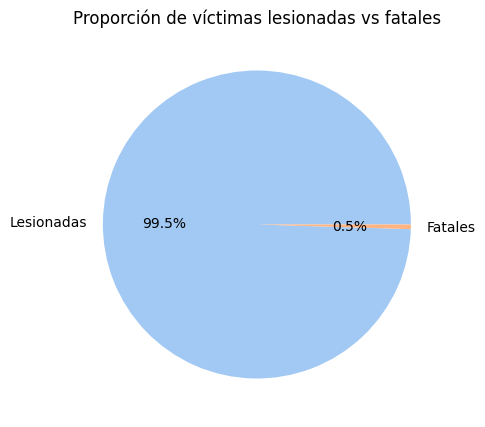

In [153]:
total_lesionadas = df_crashes['number_of_persons_injured'].sum()
total_fatales = df_crashes['number_of_persons_killed'].sum()
total_victimas = total_lesionadas + total_fatales

porcentajes_lesionadas_fatales = pd.DataFrame({
    'tipo': ['Lesionadas', 'Fatales'],
    'porcentaje': [
        (total_lesionadas / total_victimas) * 100,
        (total_fatales / total_victimas) * 100
    ]
})

plt.figure(figsize=(5,5))
plt.pie(porcentajes_lesionadas_fatales['porcentaje'], labels=porcentajes_lesionadas_fatales['tipo'], autopct='%1.1f%%')
plt.title("Proporción de víctimas lesionadas vs fatales")
plt.show()

El gráfico muestra que el 99,5 % de las víctimas de accidentes resultaron lesionadas y el 0,5 % fueron fatales.
Esto significa que, en promedio, 1 de cada 200 víctimas pierde la vida, mientras que el resto sufre lesiones de distinta gravedad.

Este valor puede tomarse como un promedio general o punto de referencia para futuros análisis de riesgo.
Por ejemplo, si en una zona o tipo de accidente la proporción de víctimas fatales supera significativamente el 0,5 %, podría considerarse un indicador de mayor peligrosidad o un punto crítico que requiere atención específica (mejor infraestructura, control de velocidad, señalización, etc.).

### Accidentes por tipo de vehículo

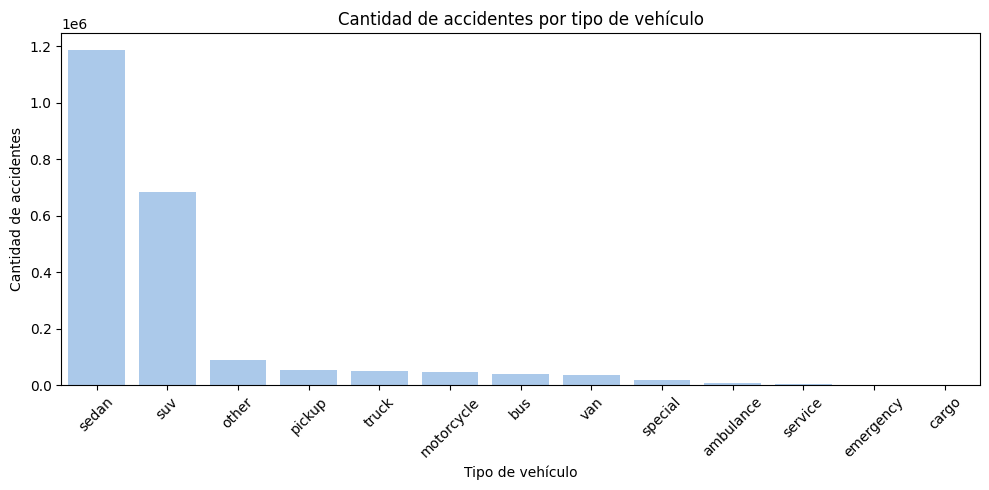

In [154]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_crashes,
    x="vehicle_type_code_1",
    order=df_crashes["vehicle_type_code_1"].value_counts().index
)
plt.title("Cantidad de accidentes por tipo de vehículo")
plt.xlabel("Tipo de vehículo")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Accidentes por distrito (borough)

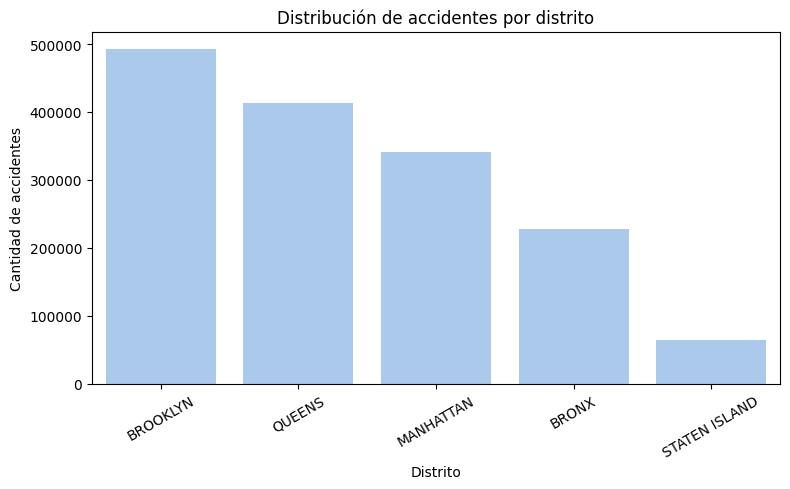

In [155]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_crashes,
    x="borough",
    order=df_crashes["borough"].value_counts().index
)
plt.title("Distribución de accidentes por distrito")
plt.xlabel("Distrito")
plt.ylabel("Cantidad de accidentes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Principales causas de accidentes

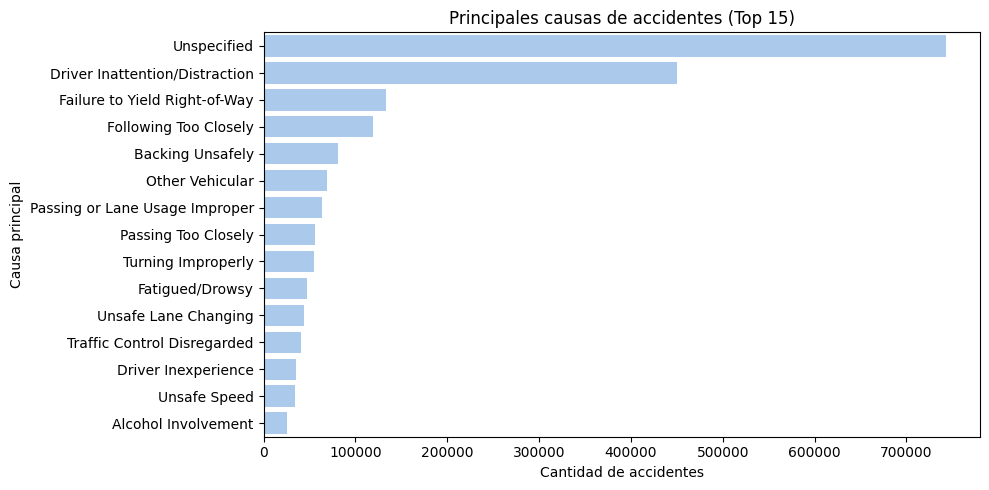

In [156]:
top_causes = df_crashes["contributing_factor_vehicle_1"].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_causes.values, y=top_causes.index)
plt.title("Principales causas de accidentes (Top 15)")
plt.xlabel("Cantidad de accidentes")
plt.ylabel("Causa principal")
plt.tight_layout()
plt.show()

# solo grafico este ya que la columna contributing_factor_vehicle_2 tiene pocos datos relevantes

Lamentablemente, la mayoría de los registros no incluye una descripción específica de las causas contribuyentes (“Unspecified”), lo que sugiere una limitación en la calidad o completitud de los datos reportados.

No obstante, entre los casos donde sí se consignó un factor contribuyente, se observan algunas tendencias claras.
Las causas más frecuentes están relacionadas con errores humanos y conductas de riesgo al volante, destacándose:

- Distracción o falta de atención del conductor, que representa el factor más común entre los accidentes reportados.

- No ceder el paso (Failure to Yield Right-of-Way) y seguir demasiado de cerca (Following Too Closely), ambos vinculados con fallas en el comportamiento vial.

- Maniobras inseguras, como retroceder de forma peligrosa (Backing Unsafely), cambios de carril inadecuados o girar incorrectamente, también aparecen con alta frecuencia.

En menor medida, factores como fatiga, exceso de velocidad o consumo de alcohol también contribuyen a los accidentes, aunque con menor proporción.

En conjunto, estos resultados reflejan que la mayoría de los accidentes tienen un origen predominantemente humano, lo que resalta la importancia de la educación vial, el control del cumplimiento de normas de tránsito y la concientización sobre la conducción responsable.

### Factores en accidentes con múltiples vehículos

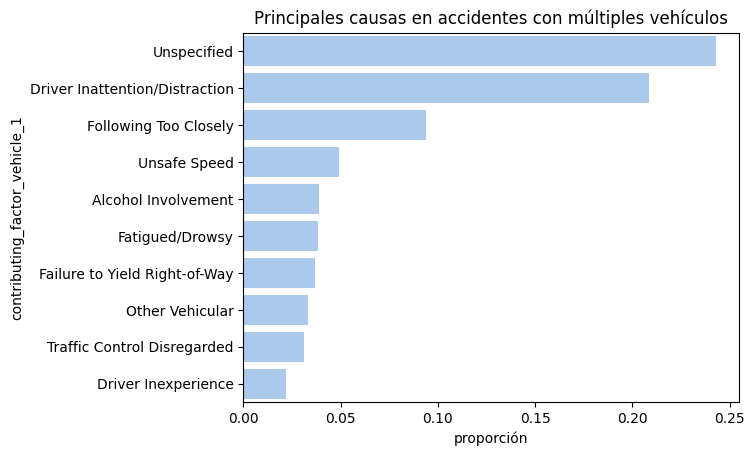

In [157]:
factores = df_crashes.groupby('multiple_crash')['contributing_factor_vehicle_1'].value_counts(normalize=True).rename('proporción').reset_index()
sns.barplot(data=factores[factores['multiple_crash']==1].head(10), x='proporción', y='contributing_factor_vehicle_1')
plt.title("Principales causas en accidentes con múltiples vehículos")
plt.show()


Comparación de causas entre accidentes simples y múltiples:

En general, los accidentes simples parecen estar más vinculados a errores individuales del conductor, problemas de atención, cansancio o conducción imprudente sin interacción con otros vehículos.

En cambio, entre los accidentes con múltiples vehículos, la distribución de causas cambia notablemente:

- Seguir demasiado de cerca (Following Too Closely) se vuelve una de las causas más comunes (9,4% de los casos múltiples, frente a apenas 5% en los simples).

- Exceso de velocidad (Unsafe Speed) y alcohol duplican aproximadamente su peso relativo respecto de los accidentes simples.

Esto sugiere que los choques múltiples están más asociados a factores de interacción entre vehículos, como la distancia insuficiente y la velocidad excesiva.

# Objetivo: reducir las muertes por accidentes en la Ciudad de Nueva York

Buscamos identificar patrones que permitan priorizar intervenciones y políticas públicas. En particular nos interesa responder:

- ¿Qué distritos concentran más muertes?
- ¿Qué tipos de vehículo están más involucrados en siniestros fatales?
- ¿Qué factores contribuyentes están más asociados a muertes?
- ¿Qué tipos de víctimas son las más frecuentes en accidentes fatales?

La meta es recopilar evidencia útil para orientar políticas que reduzcan la mortalidad vial.

### Análisis visual orientado a muertes


### Tasa de fatalidad según tipo de vehículo

C:\Users\PC\AppData\Local\Temp\ipykernel_17348\4022256266.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_vehiculos.groupby("vehicle_type")
C:\Users\PC\AppData\Local\Temp\ipykernel_17348\4022256266.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


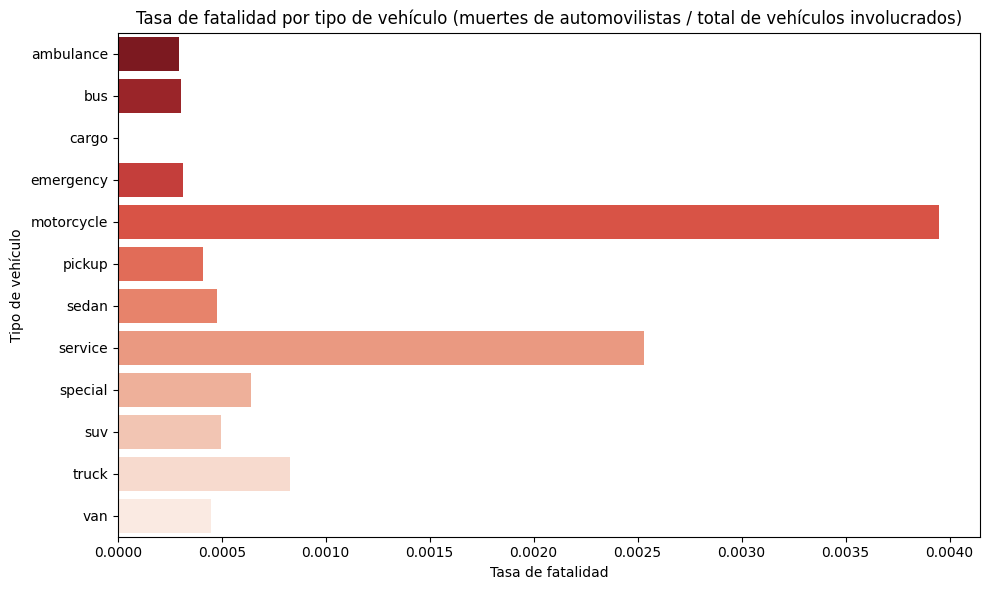

In [ ]:
df_vehiculos = pd.concat([
    df_crashes[["vehicle_type_code_1", "number_of_motorist_killed"]].rename(columns={"vehicle_type_code_1": "vehicle_type"}),
    df_crashes[["vehicle_type_code_2", "number_of_motorist_killed"]].rename(columns={"vehicle_type_code_2": "vehicle_type"})
])


df_vehiculos = df_vehiculos[df_vehiculos["vehicle_type"] != "other"]
df_vehiculos["vehicle_type"] = df_vehiculos["vehicle_type"].cat.remove_unused_categories()

veh_stats = (
    df_vehiculos.groupby("vehicle_type")
    .agg(
        total_vehiculos=("vehicle_type", "size"),
        muertes_motoristas=("number_of_motorist_killed", "sum")
    )
    .reset_index()
)

# Calcular tasa de fatalidad relativa
veh_stats["tasa_fatalidad"] = veh_stats["muertes_motoristas"] / veh_stats["total_vehiculos"]

# Ordenar por tasa
veh_stats = veh_stats.sort_values("tasa_fatalidad", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    data=veh_stats,
    x="tasa_fatalidad",
    y="vehicle_type",
    palette="Reds_r"
)
plt.title("Tasa de fatalidad por tipo de vehículo (muertes de automovilistas / total de vehículos involucrados)")
plt.xlabel("Tasa de fatalidad")
plt.ylabel("Tipo de vehículo")
plt.tight_layout()
plt.show()


### Analisis de muertes por tipo de vehiculo


Las motocicletas son, con gran diferencia, el tipo de vehículo más letal.

Representan solo una pequeña proporción del total de vehículos (134 mil de más de 4 millones analizados), pero concentran el 33% de todas las muertes de automovilistas.

Su tasa de fatalidad (0.00395) es 8 veces mayor que la de un auto (sedan) y casi 13 veces mayor que la de un bus.

Esto indica una vulnerabilidad extrema de los motociclistas, consistente con estudios globales de seguridad vial urbana.

Los vehículos de servicio (camiones de basura, barrenderas, utilitarios) también muestran una tasa relativamente alta (0.0025), aunque con baja participación absoluta en choques. Esto podría estar asociado al tipo de maniobras que realizan (en reversa, en calles estrechas, con poca visibilidad).

Sedanes y SUVs, que representan más del 75% de los vehículos involucrados, presentan tasas bajas (≈0.00048–0.0005), pero acumulan el mayor número absoluto de muertes (más de 1.500 entre ambos).
Esto sugiere que, si bien el riesgo individual es bajo, su alta exposición en el tránsito hace que sigan siendo protagonistas clave en los accidentes fatales.

Vehículos pesados (camiones, vans, pickups) tienen tasas intermedias. Aunque el número de muertes es menor, su masa y potencia implican un riesgo mayor para otros usuarios vulnerables (peatones, ciclistas).

Conclusiones:

Foco prioritario: las motocicletas deben ser el eje principal de las políticas de seguridad vial.
Las estrategias más efectivas incluyen:

- Control de velocidad y adelantamiento.

- Promoción del uso de casco y equipamiento adecuado.

- Educación vial específica para motociclistas y automovilistas sobre convivencia segura.

- Mejoras en infraestructura (carriles exclusivos o delimitados).

- Monitoreo de vehículos de servicio: revisar protocolos de maniobra y mantenimiento, especialmente en zonas urbanas con alto flujo peatonal.

### Muertes totales por distrito

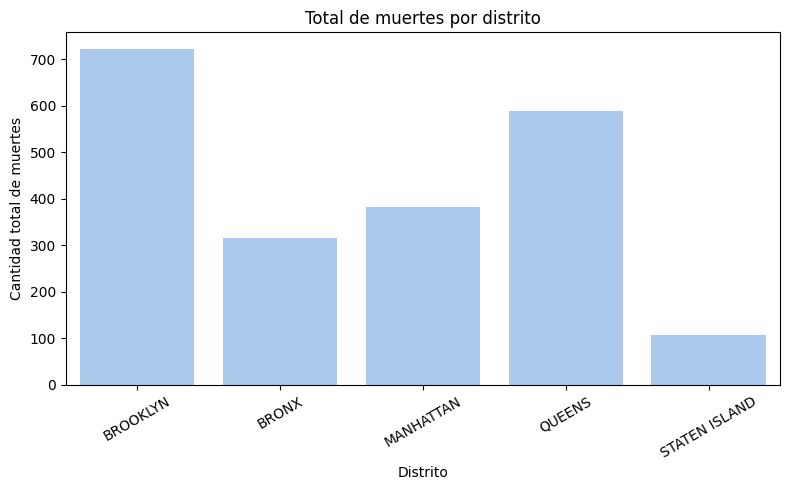

In [159]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_crashes,
    x="borough",
    y="number_of_persons_killed",
    estimator="sum",
    errorbar=None
)
plt.title("Total de muertes por distrito")
plt.xlabel("Distrito")
plt.ylabel("Cantidad total de muertes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Muertes por cada 100,000 habitantes por distrito

C:\Users\PC\AppData\Local\Temp\ipykernel_17348\4250065247.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


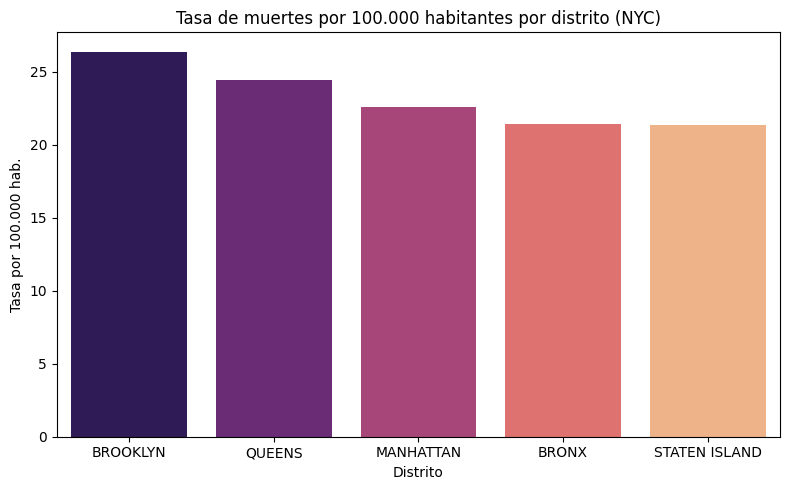

In [ ]:

df_fatal = df_crashes[df_crashes["number_of_persons_killed"] > 0].copy()

muertes_por_borough = (
    df_fatal.groupby("borough")["number_of_persons_killed"]
    .sum()
    .reset_index()
    .sort_values("number_of_persons_killed", ascending=False)
)

# (Censo 2020 población por distrito)
poblacion = {
    "BROOKLYN": 2736074,
    "QUEENS": 2405464,
    "MANHATTAN": 1694251,
    "BRONX": 1472654,
    "STATEN ISLAND": 495747
}

muertes_por_borough["poblacion"] = muertes_por_borough["borough"].map(poblacion)

# Calcular tasa cada 100.000 habitantes
muertes_por_borough["tasa_por_100k"] = (
    muertes_por_borough["number_of_persons_killed"] /
    muertes_por_borough["poblacion"]
) * 100000

plt.figure(figsize=(8,5))
sns.barplot(
    data=muertes_por_borough.sort_values("tasa_por_100k", ascending=False),
    x="borough",
    y="tasa_por_100k",
    palette="magma"
)

plt.title("Tasa de muertes por 100.000 habitantes por distrito (NYC)")
plt.xlabel("Distrito")
plt.ylabel("Tasa por 100.000 hab.")
plt.tight_layout()
plt.show()

### Muertes por distrito y oportunidades de mejora

A pesar de que Manhattan concentra uno de los mayores volúmenes de tránsito y actividad peatonal de toda la ciudad, su tasa de mortalidad vial (22.6 por cada 100.000 habitantes) es notablemente menor que la de distritos como Brooklyn (26.4) o Queens (24.4).
Esto sugiere que la densidad vehicular por sí sola no explica la cantidad de muertes, sino que las condiciones del entorno urbano y las políticas de control del tránsito pueden tener un impacto decisivo.

*Qué podemos aprender del caso de Manhattan*

Manhattan ofrece un modelo de buenas prácticas que podría replicarse en otros distritos:

- Infraestructura más segura para peatones y ciclistas:
Calles con mejor señalización, cruces peatonales elevados, y un mayor número de semáforos peatonales reducen la exposición al riesgo.

- Control de velocidad más estricto:
La presencia constante de radares, cámaras y una alta densidad de controles policiales desalienta el exceso de velocidad, una de las principales causas de accidentes fatales.

- Diseño urbano que desalienta la conducción rápida:
La estructura más compacta, con calles angostas y alto flujo peatonal, actúa como un “limitador natural” de velocidad.

- Transporte público más utilizado:
En Manhattan, la proporción de viajes en transporte público es mayor, lo que reduce la exposición al riesgo vehicular.

### Comparacion de factores contribuyentes en accidentes fatales y no fatales

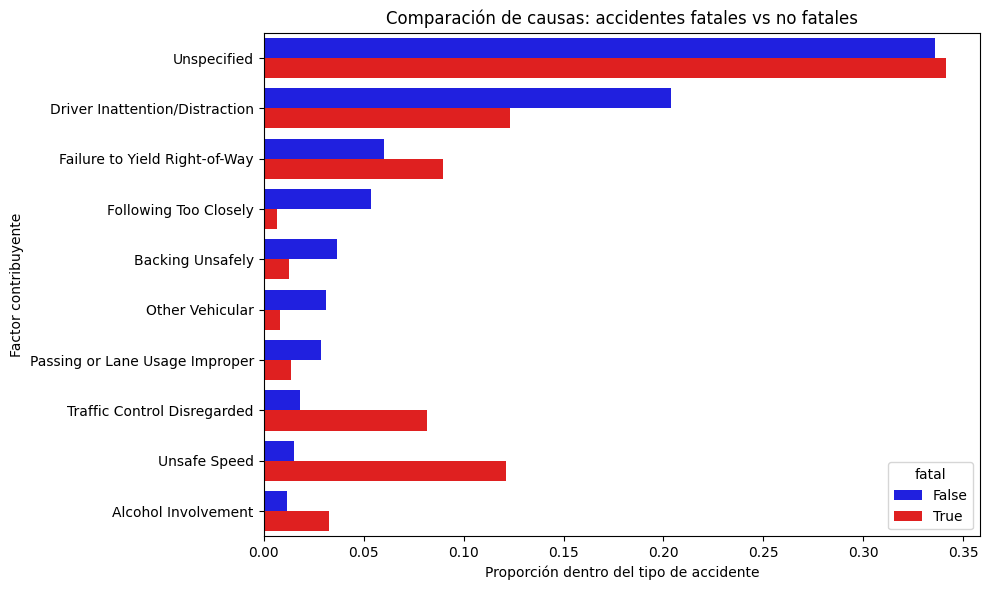

In [ ]:
df_crashes["fatal"] = df_crashes["number_of_persons_killed"] > 0

factores_comparativo = (
    df_crashes.groupby("fatal")["contributing_factor_vehicle_1"]
    .value_counts(normalize=True)
    .rename("proporción")
    .reset_index()
)

# Tomamos los 10 factores más comunes en general 
top_factores = (
    factores_comparativo.groupby("contributing_factor_vehicle_1")["proporción"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# Filtramos solo esos factores para comparar fatales vs no fatales
factores_filtrados = factores_comparativo[
    factores_comparativo["contributing_factor_vehicle_1"].isin(top_factores)
]

plt.figure(figsize=(10, 6))
sns.barplot(
    data=factores_filtrados,
    x="proporción",
    y="contributing_factor_vehicle_1",
    hue="fatal",
    palette=["blue", "red"],  # azul = no fatal, rojo = fatal
)
plt.title("Comparación de causas: accidentes fatales vs no fatales")
plt.xlabel("Proporción dentro del tipo de accidente")
plt.ylabel("Factor contribuyente")
plt.tight_layout()
plt.show()

Análisis de factores contribuyentes en accidentes fatales vs no fatales

Se observan diferencias marcadas en los factores que predominan en los siniestros con víctimas fatales:

- Distracción del conductor (Driver Inattention/Distraction) es el factor más común en accidentes no fatales (20,4%), pero su peso relativo disminuye a 12,3% en los fatales, lo que sugiere que este tipo de descuido, aunque frecuente, no suele tener consecuencias mortales en la mayoría de los casos.

- En cambio, el exceso de velocidad (Unsafe Speed) es mucho más relevante en los accidentes fatales (12,1%) que en los no fatales (1,5%). Esto indica que la velocidad es un factor crítico asociado directamente a la letalidad de los choques.

- No ceder el paso (Failure to Yield Right-of-Way) aparece en ambos grupos, pero también con mayor incidencia relativa en los fatales (9,0% vs 6,0%), mostrando que los errores de prioridad pueden derivar en colisiones severas.

- Desobedecer señales de tránsito (Traffic Control Disregarded) representa un 8,2% en los fatales, 4.5 veces más que en los no fatales (1,8%), lo que sugiere una clara relación entre conductas imprudentes y mayor mortalidad.
    
Alcohol Involvement también se triplica (3,3% en fatales vs 1,1% en no fatales), reforzando su papel como factor de riesgo letal.

En conjunto, estos resultados muestran que la diferencia entre un accidente leve y uno fatal radica menos en la distracción y más en el comportamiento temerario: velocidad, alcohol y desobediencia a normas son los factores más fuertemente asociados a muertes.

En lo personal me sorprendió que "Alcohol Involvement" represente tan poco porcentaje del total de causas, especialmente en los accidentes fatales, esperaba que fuera más alto.

###  Distribución de muertes por tipo de víctima

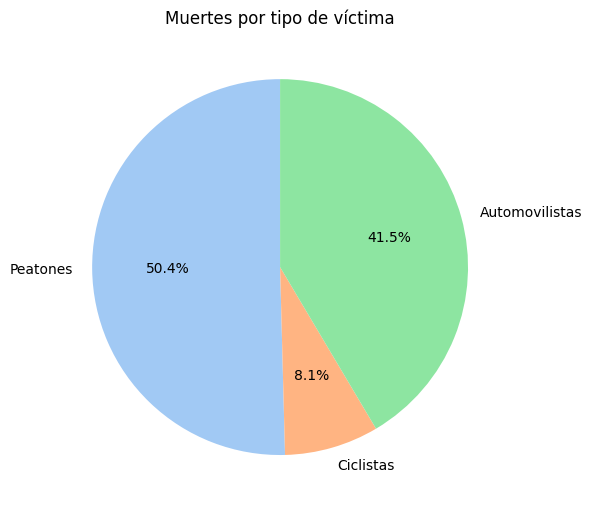

In [162]:
victim_cols = {
    "Peatones": "number_of_pedestrians_killed",
    "Ciclistas": "number_of_cyclist_killed",
    "Automovilistas": "number_of_motorist_killed"
}

victim_totals = {k: df_crashes[v].sum() for k, v in victim_cols.items()}

plt.figure(figsize=(6,6))
plt.pie(victim_totals.values(),
    labels=victim_totals.keys(),
    autopct='%1.1f%%',
    startangle=90,)
plt.title("Muertes por tipo de víctima")
plt.tight_layout()
plt.show()


Los peatones representan la mayoría de las muertes, lo que muestra su gran vulnerabilidad frente al tráfico urbano.
Esto sugiere que las políticas de seguridad vial deberían priorizar la protección de peatones, reforzando pasos peatonales, señalización y límites de velocidad.

### Evolución de muertes por tipo de víctima

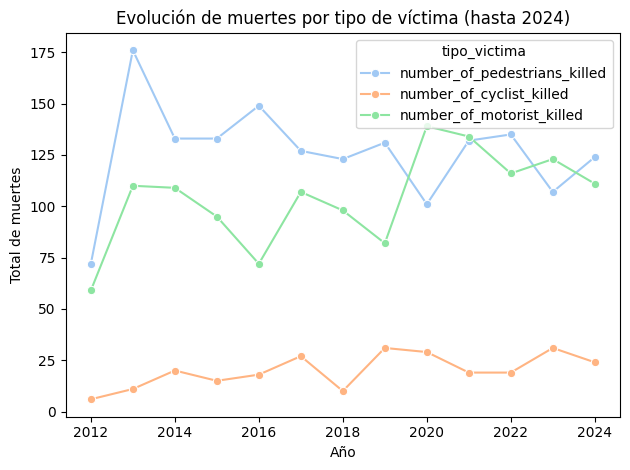

In [163]:
victimas_tiempo = (
    df_crashes.groupby("year")[["number_of_pedestrians_killed",
                              "number_of_cyclist_killed",
                              "number_of_motorist_killed"]]
    .sum()
    .reset_index()
)

# Excluir 2025 (año incompleto)
victimas_tiempo = victimas_tiempo[victimas_tiempo["year"] != 2025]

# Reestructurar para graficar
victimas_tiempo = victimas_tiempo.melt(
    id_vars="year", var_name="tipo_victima", value_name="muertes"
)

# Gráfico de líneas
sns.lineplot(data=victimas_tiempo, x="year", y="muertes", hue="tipo_victima", marker="o")
plt.title("Evolución de muertes por tipo de víctima (hasta 2024)")
plt.xlabel("Año")
plt.ylabel("Total de muertes")
plt.tight_layout()
plt.show()


### Análisis temporal de muertes por tipo de víctima

Al observar la evolución anual de las muertes en siniestros viales (excluyendo 2025 por datos incompletos), se identifican tres patrones claros:

- Peatones: muestran una reducción sostenida en el número de muertes a lo largo del tiempo. Esto podría asociarse con mejoras en la infraestructura peatonal, mayor control en cruces o campañas de concientización.

- Vehiculos: presentan un aumento en los últimos años, lo que podría reflejar un incremento del parque automotor o una mayor exposición al riesgo por congestión y velocidad en zonas urbanas.

- Ciclistas: también registran un aumento progresivo, posiblemente vinculado al crecimiento del uso de la bicicleta como medio de transporte, especialmente tras la pandemia y la expansión de ciclovías.